In [1]:
%cd ..

/eos/home-i00/d/daocampo/higgscharm


In [4]:
import yaml
import numpy as np
import mplhep as hep
import matplotlib.pyplot as plt
from coffea import util
from pathlib import Path
from coffea import processor
from matplotlib.lines import Line2D
from hist.intervals import ratio_uncertainty
from matplotlib.offsetbox import AnchoredText
from analysis.filesets.utils import get_nano_version
from coffea.lookup_tools.dense_lookup import dense_lookup
from analysis.workflows.config import WorkflowConfigBuilder


hep.style.use(hep.style.CMS)
with open("analysis/postprocess/luminosity.yaml", "r") as f:
    luminosities = yaml.safe_load(f)
with open("analysis/postprocess/style.yaml", "r") as f:
    style = yaml.safe_load(f)
plt.rcParams.update(style["rcParams"])


def get_eff_sf(eff_hist, wp, eta_region, jet_flavor, category):
    flavor_tags = {"light": 0, "c": 1, "b": 2}
    selector = {"jet_flavor": flavor_tags[jet_flavor]}
    if eta_region == "barrel":
        selector.update({"jet_abseta": slice(0.0j, 1.3j, sum)})
    else:
        selector.update({"jet_abseta": slice(1.3j, 2.5j, sum)})

    selector_numerator = {**selector, f"jet_pass_{wp}_wp": True}
    selector_denominator = {**selector, f"jet_pass_{wp}_wp": sum}

    if "category" in eff_hist[f"eff_{wp}_wp"].axes.name:
        selector_numerator.update({"category": category})
        selector_denominator.update({"category": category})

    numerator = eff_hist[f"eff_{wp}_wp"][selector_numerator]
    denominator = eff_hist[f"eff_{wp}_wp"][selector_denominator]
    efficiency = numerator / denominator

    centers = efficiency.axes[0].centers
    edges = efficiency.axes[0].edges
    xerr = edges[1:] - edges[:-1]
    yerr = ratio_uncertainty(
        num=numerator.values(),
        denom=denominator.values(),
        uncertainty_type="efficiency",
    )

    return efficiency.values(), centers, xerr, yerr

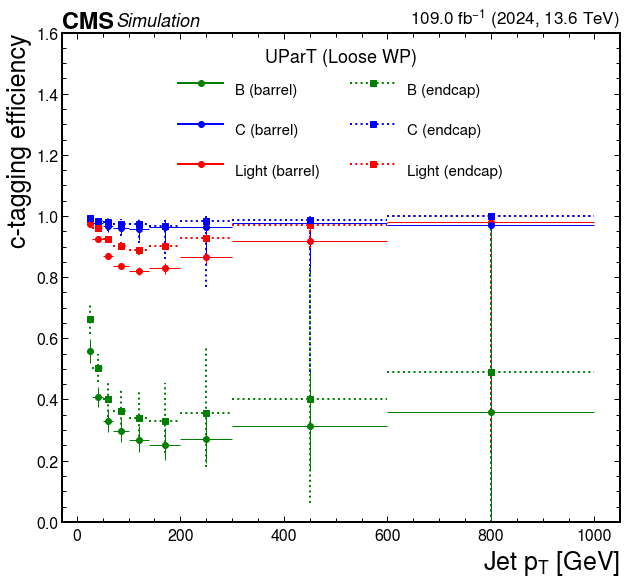

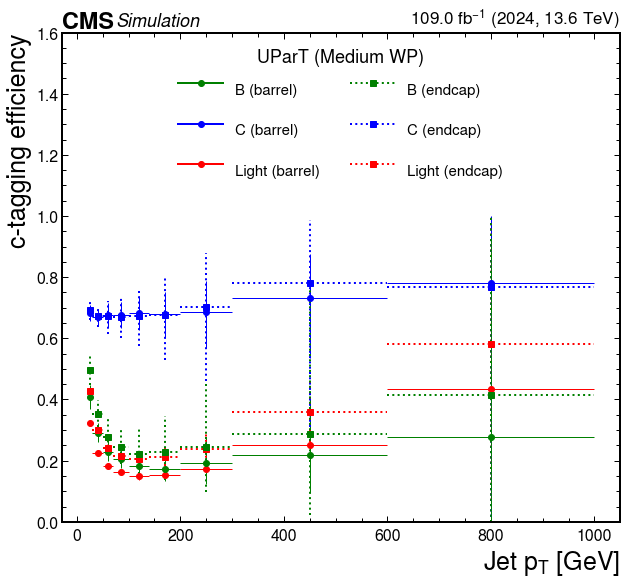

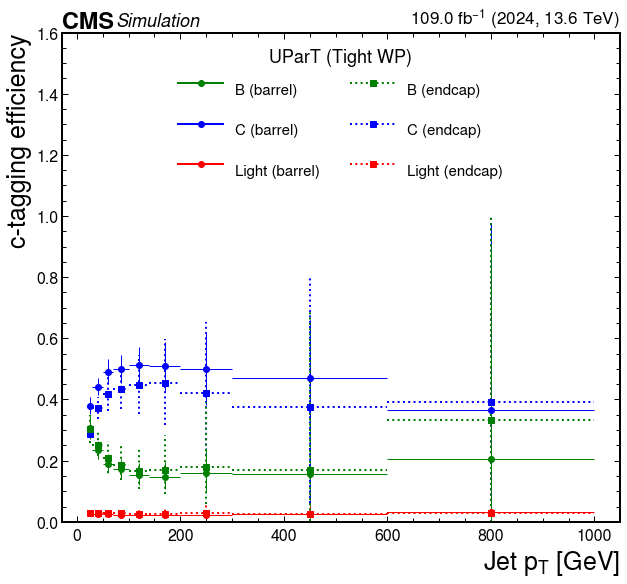

In [5]:
workflow = "ctag_eff"
year = "2024"

nano_version = get_nano_version(year)
energy = "13.6" if int(nano_version) > 9 else  "13"
tagger_map = {"9": "deepJet", "12": "ParticleNet", "15": "UParT"}


config_builder = WorkflowConfigBuilder(workflow=workflow)
workflow_config = config_builder.build_workflow_config()
categories = list(workflow_config.event_selection["categories"].keys())

# Load processed histograms from btag_eff workflow
processed_histograms_file = Path(f"outputs/{workflow}/{year}/{year}_processed_histograms.coffea")
if not processed_histograms_file.exists():
    cmd = f"python3 run_postprocess.py -w {workflow} -y {year} --postprocess"
    raise ValueError(
        f"Postprocess file not found. Please run:\n  '{cmd}'"
    )
processed_histograms = util.load(str(processed_histograms_file))
btag_eff_hist = processor.accumulate(processed_histograms.values())

for category in categories:
    for wp in ["loose", "medium", "tight"]:

        numerator_selector = {f"jet_pass_{wp}_wp": True}
        denominator_selector = {f"jet_pass_{wp}_wp": sum}
        if len(categories) > 1:
            numerator_selector.update({"category": category})
            denominator_selector.update({"category": category})
            
        numerator = btag_eff_hist[f"eff_{wp}_wp"][numerator_selector]
        denominator = btag_eff_hist[f"eff_{wp}_wp"][denominator_selector]
        efficiency = numerator / denominator
        efflookup = dense_lookup(efficiency.values(), [ax.edges for ax in efficiency.axes])
        efflookup._axes[-1] = np.array([0.0, 4.0, 5.0, 6.0])
    
        output_path = (
            f"analysis/data/ctag_efficiencies/{workflow}_{wp}_{category}_{year}.coffea"
        )
        util.save(efflookup, output_path)
    
        # plot b-tagging efficiencies
        eff_barrel_light, centers, xerr_barrel_light, yerr_barrel_light = get_eff_sf(
            btag_eff_hist, wp=wp, eta_region="barrel", jet_flavor="light", category=category
        )
        eff_barrel_c, centers, xerr_barrel_c, yerr_barrel_c = get_eff_sf(
            btag_eff_hist, wp=wp, eta_region="barrel", jet_flavor="c", category=category
        )
        eff_barrel_b, centers, xerr_barrel_b, yerr_barrel_b = get_eff_sf(
            btag_eff_hist, wp=wp, eta_region="barrel", jet_flavor="b", category=category
        )
    
        eff_endcap_light, centers, xerr_endcap_light, yerr_endcap_light = get_eff_sf(
            btag_eff_hist, wp=wp, eta_region="endcap", jet_flavor="light", category=category
        )
        eff_endcap_c, centers, xerr_endcap_c, yerr_endcap_c = get_eff_sf(
            btag_eff_hist, wp=wp, eta_region="endcap", jet_flavor="c", category=category
        )
        eff_endcap_b, centers, xerr_endcap_b, yerr_endcap_b = get_eff_sf(
            btag_eff_hist, wp=wp, eta_region="endcap", jet_flavor="b", category=category
        )
    
        fig, ax = plt.subplots(figsize=(10, 9))
        errorbar_container1 = ax.errorbar(
            centers,
            eff_barrel_light,
            xerr=xerr_barrel_light / 2,
            yerr=yerr_barrel_light,
            fmt="ro",
            elinewidth=1,
            linestyle="solid",
            linewidth=0,
            markersize=6,
        )
        errorbar_container2 = ax.errorbar(
            centers,
            eff_barrel_c,
            xerr=xerr_barrel_c / 2,
            yerr=yerr_barrel_c,
            fmt="bo",
            elinewidth=1,
            linestyle="solid",
            linewidth=0,
            markersize=6,
        )
        errorbar_container3 = ax.errorbar(
            centers,
            eff_barrel_b,
            xerr=xerr_barrel_b / 2,
            yerr=yerr_barrel_b,
            fmt="go",
            elinewidth=1,
            linestyle="solid",
            linewidth=0,
            markersize=6,
        )
    
        errorbar_container4 = ax.errorbar(
            centers,
            eff_endcap_light,
            xerr=xerr_endcap_light / 2,
            yerr=yerr_endcap_light,
            fmt="rs",
            elinewidth=1,
            linewidth=0,
            markersize=6,
        )
        errorbar_container5 = ax.errorbar(
            centers,
            eff_endcap_c,
            xerr=xerr_endcap_c / 2,
            yerr=yerr_endcap_c,
            fmt="bs",
            elinewidth=1,
            linewidth=0,
            markersize=6,
        )
        errorbar_container6 = ax.errorbar(
            centers,
            eff_endcap_b,
            xerr=xerr_endcap_b / 2,
            yerr=yerr_endcap_b,
            fmt="gs",
            elinewidth=1,
            linewidth=0,
            markersize=6,
        )
        for bar in errorbar_container4[2]:
            bar.set_linestyle(":")
            bar.set_linewidth(2)
        for bar in errorbar_container5[2]:
            bar.set_linestyle(":")
            bar.set_linewidth(2)
        for bar in errorbar_container6[2]:
            bar.set_linestyle(":")
            bar.set_linewidth(2)
    
        legend_elements = [
            Line2D(
                [0],
                [0],
                color="g",
                linewidth=2,
                linestyle="-",
                marker="o",
                markersize=6,
                label="B (barrel)",
            ),
            Line2D(
                [0],
                [0],
                color="b",
                linewidth=2,
                linestyle="-",
                marker="o",
                markersize=6,
                label="C (barrel)",
            ),
            Line2D(
                [0],
                [0],
                color="r",
                linewidth=2,
                linestyle="-",
                marker="o",
                markersize=6,
                label="Light (barrel)",
            ),
            Line2D(
                [0],
                [0],
                color="g",
                linewidth=2,
                linestyle=":",
                marker="s",
                markersize=6,
                label="B (endcap)",
            ),
            Line2D(
                [0],
                [0],
                color="b",
                linewidth=2,
                linestyle=":",
                marker="s",
                markersize=6,
                label="C (endcap)",
            ),
            Line2D(
                [0],
                [0],
                color="r",
                linewidth=2,
                linestyle=":",
                marker="s",
                markersize=6,
                label="Light (endcap)",
            ),
        ]
        ax.legend(
            handles=legend_elements,
            loc="upper center",
            handlelength=3,
            handleheight=3,
            fontsize=15,
            ncols=2,
            title=f"{tagger_map[nano_version]} ({wp.capitalize()} WP)",
        )
        ax.set(
            ylim=(0, 1.6),
            ylabel="c-tagging efficiency",
            xlabel="Jet $p_T$ [GeV]",
        )
        hep.cms.lumitext(
            f"{luminosities[year] * 1e-3:.1f} fb$^{{-1}}$ ({year}, {energy} TeV)"
        )
        hep.cms.text("Simulation", loc=0, ax=ax)
        fig.savefig(f"notebooks/{workflow}_{wp}_{category}_{year}.pdf")